In [1]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator

In [2]:
# setting pixels and angles
n_pixels = 265
n_angles = 50

## setting up

In [3]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [4]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


## Normal equations

In [5]:
def apply_operator(weights_k, alpha, x):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(weights_k)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

In [6]:
def CG_tv(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = b - apply_operator(weights_k=Wk, alpha=alpha, x=u0)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):

        # zk = Apk
        zk = apply_operator(weights_k=Wk, alpha=alpha, x=pk)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

In [7]:
def tv_solver_normalcg(initial, inner, outer, A, b, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        max_outer:  Number of outer iterations (scalar)
        max_inner:  Number of CG interations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        b:          The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """

    uk = initial.copy()

    # create lhs, A^Tb
    lhs = A.adjoint(b)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    for k in range(outer):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()
        #print("Before reweighting:", uk_grad_np)

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1/2)

        # convert back to ImageData
        uk_reweighted = ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        cg_output = CG_tv(uk, inner, lhs, alpha, uk_reweighted)
        
        uk = cg_output

    return uk


In [19]:
x0 = ig.allocate(0)
alpha = 1e-6
oh_no = tv_solver_normalcg(x0, 100, 10, A, sino, alpha, 0.0001)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 79 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


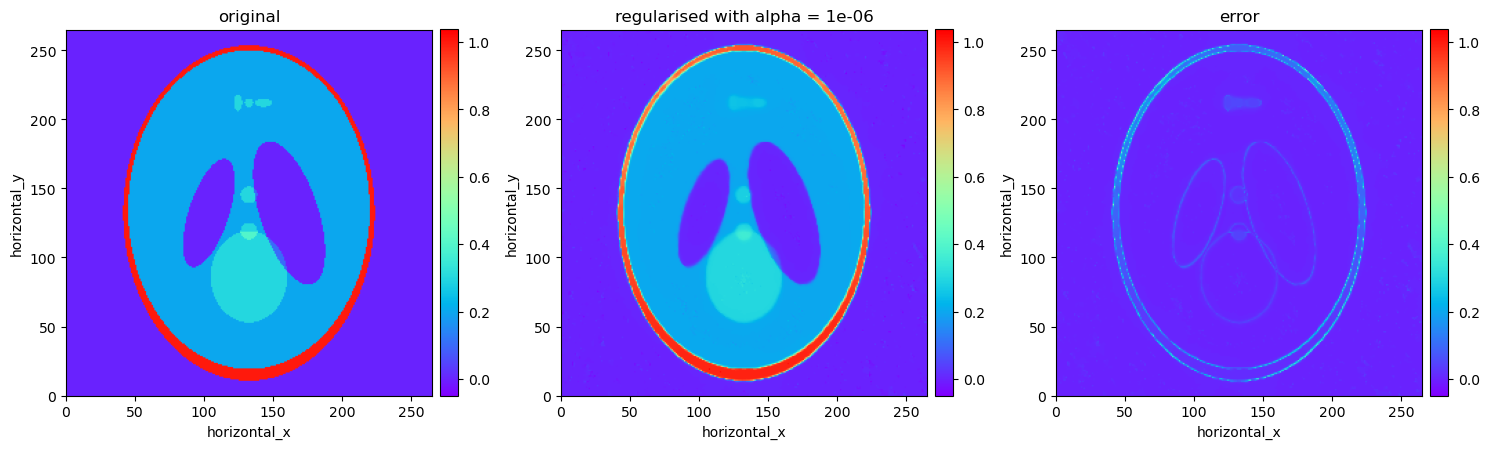

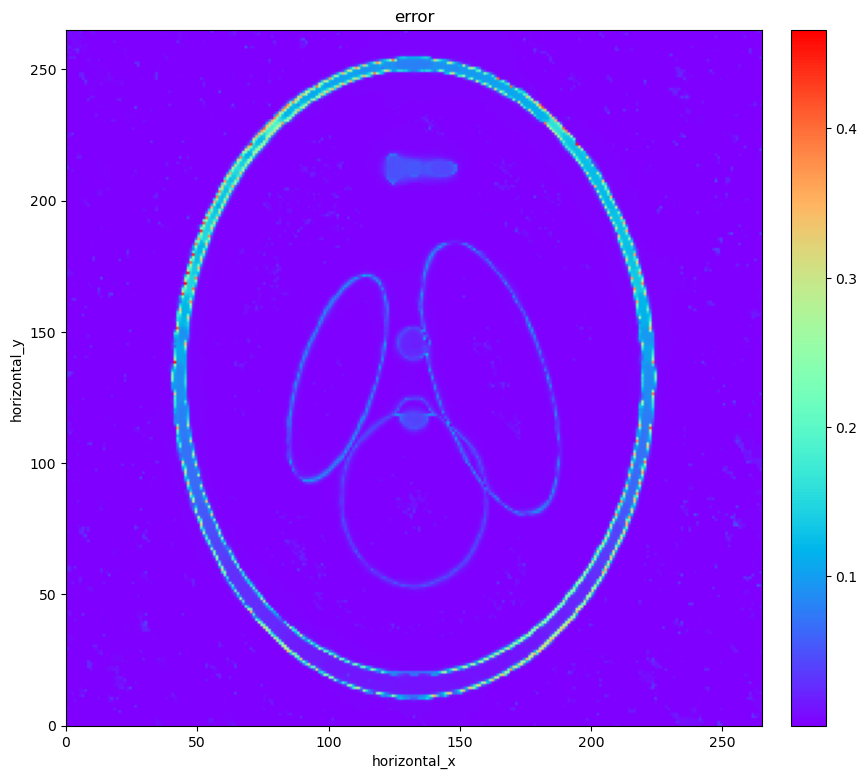

In [20]:
show2D([phantom, oh_no, (oh_no - phantom).abs()], 
       ['original', f'regularised with alpha = {alpha}', 'error'], 
       cmap=cmap, fix_range=True, num_cols =3)

show2D([(phantom - oh_no).abs()], ['error'], cmap=cmap)

In [ ]:
def CG_tv(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG
    """

    u0 = initial.copy()
    r0 = b - apply_operator(weights_k=Wk, alpha=alpha, x=u0)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):
        zk = apply_operator(weights_k=Wk, alpha=alpha, x=pk)

        # NOTE: might need to find something better than adding 1e-6
        alpha_k = (pk.dot(rk.conjugate()))/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        temp = apply_operator(weights_k=Wk, alpha=alpha, x=rk_plus_one)
        beta_k = (-pk.dot(temp.conjugate()))/(pk.dot(zk.conjugate()))

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk